# Wikimedia ID Content Creation Analysis

## Project Description
This repository contains an end-to-end data analysis pipeline and Streamlit dashboard evaluating participant retention dynamics, event typologies, and content contribution profiles across Wikimedia Indonesia's Wikidata program campaign (2025–2026). By categorizing events into Wikilatih (training), Datathon (competitions), Kopdar (gatherings), and Pemagangan (internships), the project analyzes top-of-funnel acquisition, returner repeat rates, and normalized content productivity per editor.

## Data Sources
* **Outreach Dashboard CSVs:** Campaign datasets provided by Wikimedia Indonesia containing course summaries (`df_courses`), participant registration logs (`df_students`), and Wikidata edit activity records (`df_wikidata`).

## Licenses
* **Code & Notebooks:** MIT License
* **Data & Documentation:** CC BY-SA 4.0 International (Creative Commons Attribution-ShareAlike 4.0 International)

# Preparation

In [1]:
# Import data analysis and visualization libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

# Import file system libraries
import os
import glob

# Set visual style for visualization
sns.set_theme(style="whitegrid")

In [2]:
# Set display options for clean notebook output
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)

In [3]:
# Base URL for raw data on GitHub
GITHUB_RAW_BASE = "https://raw.githubusercontent.com/thequerytrailblazer/wikimedia-id-retention-analysis/refs/heads/master/data/source/"

# File names
FILE_COURSES = "data_dan_teknologi_wikimedia_indonesia_2025-campaign_courses-2026-08-27.csv"
FILE_STUDENTS = "data_dan_teknologi_wikimedia_indonesia_2025-campaign_students-with_courses-2026-08-27.csv"
FILE_WIKIDATA = "data_dan_teknologi_wikimedia_indonesia_2025-campaign_wikidata-2026-08-27.csv"

# Load datasets directly from GitHub with semicolon separator
df_courses = pd.read_csv(os.path.join(GITHUB_RAW_BASE, FILE_COURSES), sep=';')
df_students = pd.read_csv(os.path.join(GITHUB_RAW_BASE, FILE_STUDENTS), sep=';')
df_wikidata = pd.read_csv(os.path.join(GITHUB_RAW_BASE, FILE_WIKIDATA), sep=';')

In [4]:
# Quick validation of loaded data structures
print(f"df_courses loaded: {df_courses.shape}")
print(f"df_students loaded: {df_students.shape}")
print(f"df_wikidata loaded: {df_wikidata.shape}")

df_courses loaded: (33, 24)
df_students loaded: (446, 3)
df_wikidata loaded: (31, 28)


# Data Cleaning

In [5]:
# Clean course and student datasets by filtering out duplicate backup events (- Cadang)
df_courses_clean = df_courses[~df_courses['course_slug'].str.contains('- Cadang', na=False)].copy()
df_students_clean = df_students[~df_students['course'].str.contains('- Cadang', na=False)].copy()
df_wikidata_clean = df_wikidata[~df_wikidata['course name'].str.contains('- Cadang', na=False)].copy()

In [6]:
# Standardize datetime columns
df_courses_clean['start_date'] = pd.to_datetime(df_courses_clean['start_date'], errors='coerce')
df_students_clean['registered_at'] = pd.to_datetime(df_students_clean['registered_at'], errors='coerce')

In [7]:
# Merge df_students with df_courses on event identifiers
df_merged = pd.merge(
    df_students_clean,
    df_courses_clean[['course_slug', 'title', 'start_date']],
    left_on='course',
    right_on='course_slug',
    how='inner'
)

In [8]:
# Validation check
print(f"Cleaned Courses Count: {len(df_courses_clean)}")
print(f"Cleaned Students Records Count: {len(df_students_clean)}")
print(f"Merged Dataframe Shape: {df_merged.shape}")

Cleaned Courses Count: 33
Cleaned Students Records Count: 446
Merged Dataframe Shape: (446, 6)


# Feature Engineering

In [9]:
# Course category

# Combine course_slug and title into a single lowercase text series
text_series = (df_merged['course_slug'].fillna('') + ' ' + df_merged['title'].fillna('')).str.lower()

# Define conditions and corresponding choices for vectorized mapping
conditions = [
    text_series.str.contains('wikilatih', na=False),
    text_series.str.contains('datathon|geodatathon', na=False),
    text_series.str.contains('kopdar', na=False),
    text_series.str.contains('pemagangan', na=False)
]

choices = ['Wikilatih', 'Datathon', 'Kopdar', 'Pemagangan']

# Apply np.select for vectorized classification
df_merged['event_type'] = np.select(conditions, choices, default='Other')

In [10]:
# Identify each user's first event date across the dataset
first_events = df_merged.groupby('username')['start_date'].min().reset_index()
first_events.rename(columns={'start_date': 'first_event_date'}, inplace=True)

In [11]:
# Calculate account age in days relative to FIRST event and lock cohort
df_merged = pd.merge(df_merged, first_events, on='username', how='left')
df_merged['account_age_days'] = (df_merged['first_event_date'] - df_merged['registered_at']).dt.total_seconds() / (24 * 3600)
df_merged['user_cohort'] = np.where(df_merged['account_age_days'] <= 7, 'New User', 'Existing User')

In [12]:
# Validation check
print("Event Type Distribution:")
print(df_merged['event_type'].value_counts())
print("\nUnique Users per Cohort:")
print(df_merged.groupby('user_cohort')['username'].nunique())

Event Type Distribution:
event_type
Wikilatih     247
Kopdar        104
Datathon       93
Pemagangan      2
Name: count, dtype: int64

Unique Users per Cohort:
user_cohort
Existing User    207
New User         165
Name: username, dtype: int64


# Exploratory Data Analysis

## Cohort Composition

In [13]:
# Cohort composition by Event Type (New vs. Existing split per event type)
cohort_by_type = pd.crosstab(
    df_merged['event_type'],
    df_merged['user_cohort'],
    normalize='index'
) * 100

print("=== Cohort Composition by Event Type (%) ===")
print(cohort_by_type.round(2))
print("\n" + "="*50 + "\n")

=== Cohort Composition by Event Type (%) ===
user_cohort  Existing User  New User
event_type                          
Datathon             91.40      8.60
Kopdar               92.31      7.69
Pemagangan           50.00     50.00
Wikilatih            37.25     62.75




## Users First Event Analysis

In [14]:
# First-Event Repeat Rate Calculation
# Find each user's chronological FIRST event record
df_sorted = df_merged.sort_values(by=['username', 'start_date']).reset_index(drop=True)
first_user_events = df_sorted.groupby('username').first().reset_index()

# Count total events attended per user
user_event_counts = df_merged.groupby('username')['start_date'].nunique().reset_index()
user_event_counts.rename(columns={'start_date': 'total_events_attended'}, inplace=True)

In [15]:
# Merge back to first event user profile
user_retention_profiles = pd.merge(first_user_events, user_event_counts, on='username')
user_retention_profiles['is_repeat_user'] = user_retention_profiles['total_events_attended'] > 1

# Group repeat rate by FIRST event_type and user_cohort
repeat_rate_by_type = user_retention_profiles.groupby(['event_type', 'user_cohort']).agg(
    total_first_timers=('username', 'count'),
    repeat_users=('is_repeat_user', 'sum'),
    repeat_rate_pct=('is_repeat_user', lambda x: (x.sum() / x.count()) * 100)
).reset_index()

In [16]:
print("=== Repeat Rate by Entry Channel & Cohort ===")
print(repeat_rate_by_type.round(2))
print("\n" + "="*50 + "\n")

=== Repeat Rate by Entry Channel & Cohort ===
   event_type    user_cohort  total_first_timers  repeat_users  repeat_rate_pct
0    Datathon  Existing User                  50            23            46.00
1    Datathon       New User                   3             1            33.33
2      Kopdar  Existing User                  72            13            18.06
3      Kopdar       New User                   7             0             0.00
4  Pemagangan  Existing User                   1             0             0.00
5  Pemagangan       New User                   1             1           100.00
6   Wikilatih  Existing User                  84            11            13.10
7   Wikilatih       New User                 154             4             2.60




## Event Outlier

In [17]:
# 3. Outlier Check: Event-by-Event breakdown within each Event Type
event_level_breakdown = df_merged.groupby(['event_type', 'title']).agg(
    total_participants=('username', 'count'),
    new_users=('user_cohort', lambda x: (x == 'New User').sum()),
    existing_users=('user_cohort', lambda x: (x == 'Existing User').sum())
).reset_index()

event_level_breakdown['new_user_pct'] = (event_level_breakdown['new_users'] / event_level_breakdown['total_participants']) * 100

In [18]:
print("=== Event-Level Outlier Check (Sample Rows) ===")
print(event_level_breakdown.sort_values(by=['event_type', 'total_participants'], ascending=[True, False]).head(10).round(2))

=== Event-Level Outlier Check (Sample Rows) ===
   event_type                                              title  total_participants  new_users  existing_users  new_user_pct
0    Datathon                 Datathon Bulan Wiki Perempuan 2026                  31          4              27         12.90
2    Datathon                           Geodatathon Agustus 2025                  26          0              26          0.00
3    Datathon                 Geodatathon Desember 2025 - Cadang                  23          3              20         13.04
1    Datathon                           Datathon Musik Indonesia                  13          1              12          7.69
6      Kopdar  Kopdar Wikidata Daluring Jambi x Jakarta Janua...                  16          4              12         25.00
4      Kopdar                Kopdar Wikidata Bandung 7 Juni 2026                  13          0              13          0.00
11     Kopdar             Kopdar Wikidata Yogyakarta 24 Mei 2026      

## Content output per user by Event Type

In [19]:
# Map event_type onto df_courses_clean using vectorized string matching
courses_slug_title = (df_courses_clean['course_slug'].fillna('') + ' ' + df_courses_clean['title'].fillna('')).str.lower()

conditions_courses = [
    courses_slug_title.str.contains('wikilatih', na=False),
    courses_slug_title.str.contains('geodatathon|datathon', na=False),
    courses_slug_title.str.contains('kopdar', na=False),
    courses_slug_title.str.contains('pemagangan', na=False)
]

df_courses_clean['event_type'] = np.select(conditions_courses, choices, default='Other')

In [20]:
# Merge df_wikidata_clean with df_courses_clean to link output metrics with editors and event_type
df_wikidata_merged = pd.merge(
    df_wikidata_clean,
    df_courses_clean[['title', 'course_slug', 'event_type', 'editors']],
    left_on='course name',
    right_on='title',
    how='inner'
)

In [21]:
# Aggregate totals by event_type
content_by_type = df_wikidata_merged.groupby('event_type').agg(
    total_events=('course name', 'count'),
    total_editors=('editors', 'sum'),
    total_claims_created=('claims created', 'sum'),
    total_items_created=('items created', 'sum'),
    total_labels_added=('labels added', 'sum')
).reset_index()

In [22]:
# Normalize metrics per editor (Output per Editor ratio)
content_by_type['claims_per_editor'] = content_by_type['total_claims_created'] / content_by_type['total_editors']
content_by_type['items_per_editor'] = content_by_type['total_items_created'] / content_by_type['total_editors']
content_by_type['labels_per_editor'] = content_by_type['total_labels_added'] / content_by_type['total_editors']

In [23]:
print("=== Content Output per Editor by Event Type ===")
print(content_by_type[['event_type', 'total_events', 'total_editors', 'claims_per_editor', 'items_per_editor', 'labels_per_editor']].round(2))

=== Content Output per Editor by Event Type ===
   event_type  total_events  total_editors  claims_per_editor  items_per_editor  labels_per_editor
0    Datathon             4             93            1002.22             45.83            1410.74
1      Kopdar             8             92              14.87              1.18               4.08
2  Pemagangan             2              2              73.00              8.00              23.50
3   Wikilatih            15            233               9.08              0.86               1.88


# Data Visualization

In [24]:
# Bar Chart: Cohort Composition (%) by Event Type
fig1 = px.bar(
    cohort_by_type.reset_index(),
    x='event_type',
    y=['New User', 'Existing User'],
    title='Cohort Composition Breakdown by Event Format (%)',
    labels={'value': 'Percentage (%)', 'event_type': 'Event Format', 'variable': 'User Cohort'},
    barmode='stack',
    template='plotly_white'
)
fig1.show()

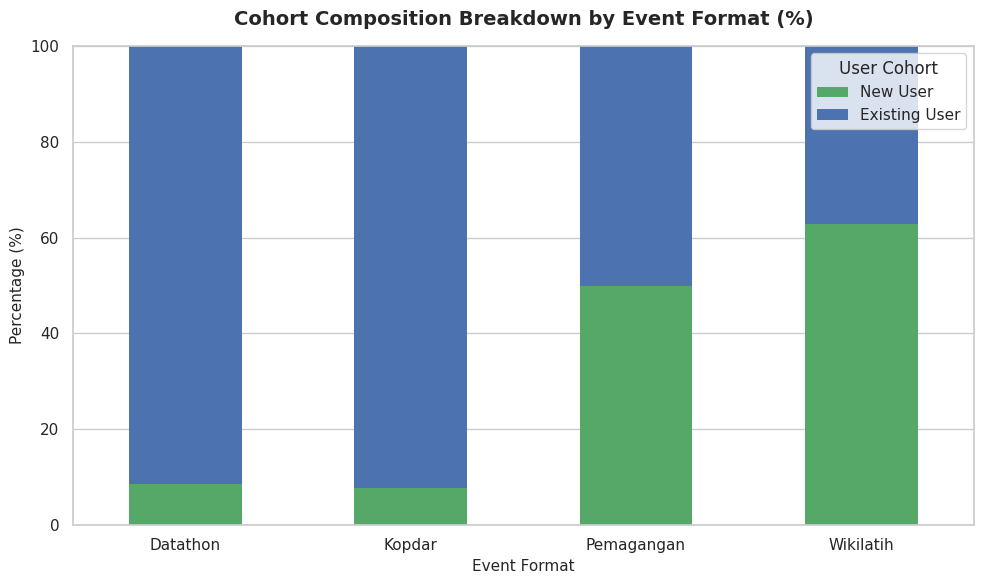

In [25]:
# Matplotlib Bar Chart: Cohort Composition Breakdown (%) by Event Format
fig1mpl, ax1 = plt.subplots(figsize=(10, 6))

cohort_plot_df = cohort_by_type[['New User', 'Existing User']]
cohort_plot_df.plot(
    kind='bar',
    stacked=True,
    ax=ax1,
    color=['#55A868', '#4C72B0'],
    edgecolor='none'
)

ax1.set_title('Cohort Composition Breakdown by Event Format (%)', fontsize=14, fontweight='bold', pad=15)
ax1.set_xlabel('Event Format', fontsize=11)
ax1.set_ylabel('Percentage (%)', fontsize=11)
ax1.set_ylim(0, 100)
ax1.legend(title='User Cohort', frameon=True)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [26]:
# Bar Chart: First-Event Repeat Rate by Entry Channel
fig2 = px.bar(
    repeat_rate_by_type,
    x='event_type',
    y='repeat_rate_pct',
    color='user_cohort',
    barmode='group',
    title='Returner Repeat Rate (%) by First Attended Event Format',
    labels={'repeat_rate_pct': 'Repeat Return Rate (%)', 'event_type': 'First Event Format', 'user_cohort': 'Cohort'},
    text_auto='.1f',
    template='plotly_white'
)
fig2.show()

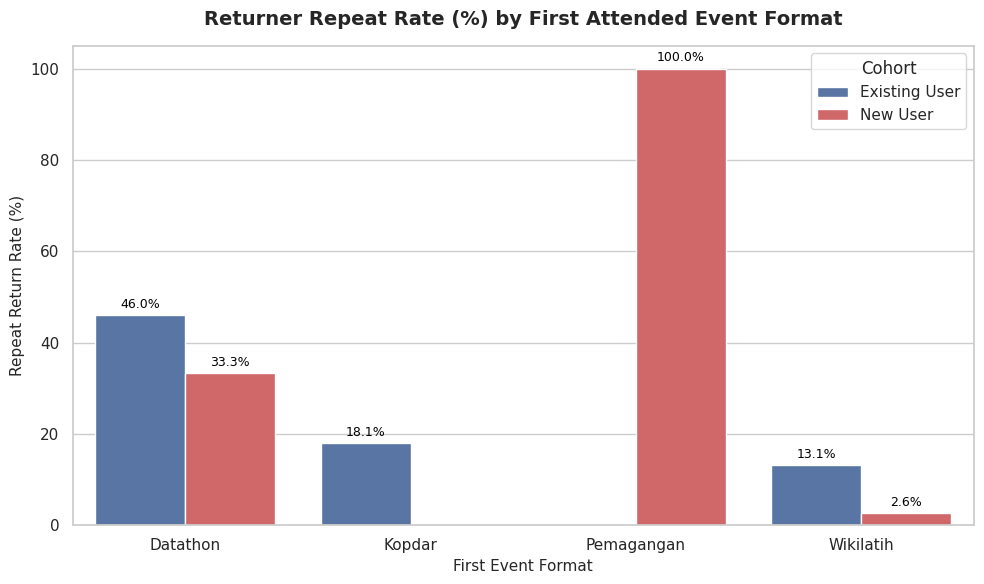

In [27]:
# Matplotlib Bar Chart: Returner Repeat Rate (%) by First Event Format
fig2mpl, ax2 = plt.subplots(figsize=(10, 6))

sns.barplot(
    data=repeat_rate_by_type,
    x='event_type',
    y='repeat_rate_pct',
    hue='user_cohort',
    palette={'New User': '#E15759', 'Existing User': '#4C72B0'},
    ax=ax2
)

# Add numeric value annotations above each bar
for p in ax2.patches:
    height = p.get_height()
    if not np.isnan(height) and height > 0:
        ax2.annotate(
            f'{height:.1f}%',
            (p.get_x() + p.get_width() / 2., height),
            ha='center', va='bottom',
            fontsize=9, color='black',
            xytext=(0, 3), textcoords='offset points'
        )

ax2.set_title('Returner Repeat Rate (%) by First Attended Event Format', fontsize=14, fontweight='bold', pad=15)
ax2.set_xlabel('First Event Format', fontsize=11)
ax2.set_ylabel('Repeat Return Rate (%)', fontsize=11)
ax2.set_ylim(0, 105)
ax2.legend(title='Cohort', frameon=True)
plt.tight_layout()
plt.show()

In [28]:
# Bar Chart: Normalized Content Output per Editor by Event Type
fig3 = px.bar(
    content_by_type,
    x='event_type',
    y=['claims_per_editor', 'labels_per_editor', 'items_per_editor'],
    title='Normalized Content Output Metrics per Editor by Event Format',
    labels={'value': 'Average Actions per Editor', 'event_type': 'Event Format', 'variable': 'Metric'},
    barmode='group',
    log_y=True,  # Log scale used due to significant variance in Datathon output
    template='plotly_white'
)
fig3.show()

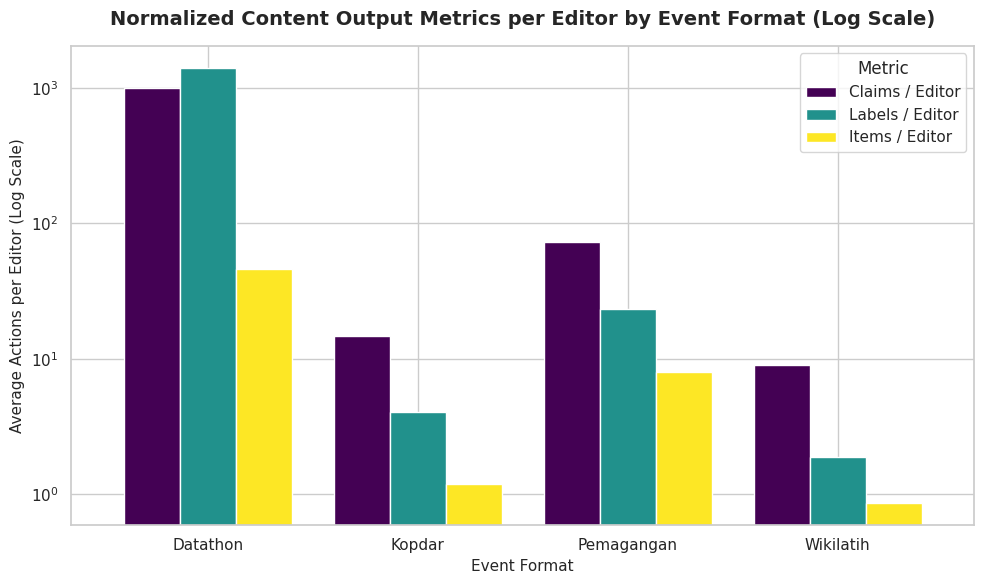

In [29]:
# Matplotlib Bar Chart: Normalized Content Output Metrics per Editor
fig3mpl, ax3 = plt.subplots(figsize=(10, 6))

content_plot_df = content_by_type.set_index('event_type')[['claims_per_editor', 'labels_per_editor', 'items_per_editor']]
content_plot_df.plot(
    kind='bar',
    ax=ax3,
    colormap='viridis',
    width=0.8
)

ax3.set_yscale('log')  # Log scale to manage scale variance from Datathons
ax3.set_title('Normalized Content Output Metrics per Editor by Event Format (Log Scale)', fontsize=14, fontweight='bold', pad=15)
ax3.set_xlabel('Event Format', fontsize=11)
ax3.set_ylabel('Average Actions per Editor (Log Scale)', fontsize=11)
ax3.legend(['Claims / Editor', 'Labels / Editor', 'Items / Editor'], title='Metric', frameon=True)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

# Data exports

In [30]:
# Export Matplotlib Figures as PNG images
fig1mpl.savefig('cohort_composition_breakdown.png', dpi=300, bbox_inches='tight')
fig2mpl.savefig('repeat_rate_by_entry_channel.png', dpi=300, bbox_inches='tight')
fig3mpl.savefig('content_output_per_editor.png', dpi=300, bbox_inches='tight')

In [31]:
# Export Plotly Figures as standalone HTML files
fig1.write_html("cohort_composition_breakdown.html")
fig2.write_html("repeat_rate_by_entry_channel.html")
fig3.write_html("content_output_per_editor.html")

In [32]:
# Clean merged retention dataset (User-Event level with event_type and locked cohort)
df_merged.to_csv('retention_cleaned.csv', index=False)

# User-level retention profile (1 row per user with total events attended and first event type)
user_retention_profiles.to_csv('user_retention_profiles.csv', index=False)

# Content output aggregated by event type (Step 5 metrics)
content_by_type.to_csv('content_by_event_type.csv', index=False)

# Event-level breakdown (Outlier check dataset)
event_level_breakdown.to_csv('event_level_breakdown.csv', index=False)

## Summary, Conclusion, and Recommendations

---

### Executive Summary

This analysis evaluated participant engagement and retention across Wikimedia Indonesia’s 2025–2026 program campaign. By categorizing activities into **Wikilatih** (training), **Datathon** (competitions), **Kopdar** (community gatherings), and **Pemagangan** (internships), the project examined top-of-funnel user acquisition, long-term return rates, and normalized content output per editor.

1. **Wikilatih** serves as the primary gateway for new contributor acquisition, drawing **62.75% New Users** ($\le 7$ days account age at first attendance).
2.**Datathons** (91.40% Existing Users) and **Kopdar** sessions (92.31% Existing Users) draw almost exclusively from established community members.
3. New users joining via **Wikilatih** experience a severe participation drop-off, yielding a post-onboarding repeat return rate of only **2.60%** (4 out of 154 users returning for subsequent events).
4. **Datathons** generate massive editing volume, averaging **1,002.22 claims** and **1,410.74 labels** per editor, compared to lower volume in introductory training environments.

---

### Key Findings & Conclusion

* Event typologies serve fundamentally different operational objectives within the Wikimedia ecosystem. Wikilatih creates top-of-funnel awareness, Kopdar maintains core community cohesion, and Datathons drive structured data productivity.
* While Wikilatih successfully attracts first-time editors, there is a structural drop-off immediately following initial training. Community retention is currently sustained almost entirely by pre-existing account holders.
* High-volume data creation is heavily concentrated among experienced editors participating in competitive formats. Introductory workshops naturally yield lower edit counts per user as participants navigate Wikidata's initial learning curve.

---

### Strategic Recommendations

1. **Structured Post-Wikilatih Activation Pathways**
   * Implement automated follow-up communication within 14 days of a Wikilatih workshop.
   * Explicitly invite new editors to localized Kopdar gatherings or beginner-friendly Datathon tracks to bridge the gap between initial training and return attendance.

2. **Targeted Audience Acquisition**
   * Shift specialized Wikilatih outreach toward academic institutions, GLAM partners, and domain-specific research groups whose existing technical background reduces onboarding friction.

3. **In-Session Feedback Loops**
   * Incorporate real-time data visualization tools (such as SPARQL query results or dynamic Wikidata dashboards) into introductory training sessions to demonstrate immediate edit impact to first-time contributors.